**Project Title**                                                
Urban Traffic Flow Prediction and Mobility Insights Extraction

**Problem Statemen**t: Urban traffic congestion leads to delays, increased fuel consumption, and environmental impact. Predicting traffic density (Low, Medium, High) based on factors like vehicle type, weather, time of day, and economic conditions can help optimize traffic management, improve urban mobility, and inform city planning.

**Description**: This project uses a dataset containing urban traffic sensor readings (e.g., vehicle counts, speeds, and contextual factors) to build machine learning models for predicting traffic density. The models will uncover mobility insights, such as how weather, peak hours, or random events affect traffic conditions across cities (New York, Los Angeles, Chicago). The insights can guide traffic signal optimization, route planning, and policy decisions.

In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
import joblib

In [2]:
# Load the dataset
df = pd.read_csv('dt.csv')

# Display first few rows
print(df.head())

          City Vehicle Type Weather Economic Condition Day Of Week  \
0     New York          Car   Sunny             Stable      Monday   
1     New York          Car   Sunny             Stable      Monday   
2     New York          Bus   Rainy             Stable     Tuesday   
3  Los Angeles          Car  Cloudy             Stable   Wednesday   
4  Los Angeles          Car   Sunny             Stable    Thursday   

   Hour Of Day  Speed  Is Peak Hour  Random Event Occurred  \
0            8     60          True                  False   
1           12     55          True                  False   
2           16     40         False                  False   
3           10     65         False                  False   
4           18     50          True                   True   

   Energy Consumption Traffic Density  
0                  50          Medium  
1                  48            High  
2                  60            High  
3                  45             Low  
4     

**Explore and Understand the Data**

In [3]:
# Basic info
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   City                   36 non-null     object
 1   Vehicle Type           36 non-null     object
 2   Weather                36 non-null     object
 3   Economic Condition     36 non-null     object
 4   Day Of Week            36 non-null     object
 5   Hour Of Day            36 non-null     int64 
 6   Speed                  36 non-null     int64 
 7   Is Peak Hour           36 non-null     bool  
 8   Random Event Occurred  36 non-null     bool  
 9   Energy Consumption     36 non-null     int64 
 10  Traffic Density        36 non-null     object
dtypes: bool(2), int64(3), object(6)
memory usage: 2.7+ KB
None
       Hour Of Day      Speed  Energy Consumption
count    36.000000  36.000000           36.000000
mean     13.000000  47.888889           52.666667
std       3.414256  

**Observations:**

1.   The dataset has 36 rows and 11 columns.
2.   Columns: City, Vehicle Type, Weather, Economic Condition, Day Of Week (categorical); Hour Of Day, Speed, Energy Consumption (numerical); Is Peak Hour, Random Event Occurred (boolean); Traffic Density (target, categorical).

3. No missing values.





**Univariate Analysis**

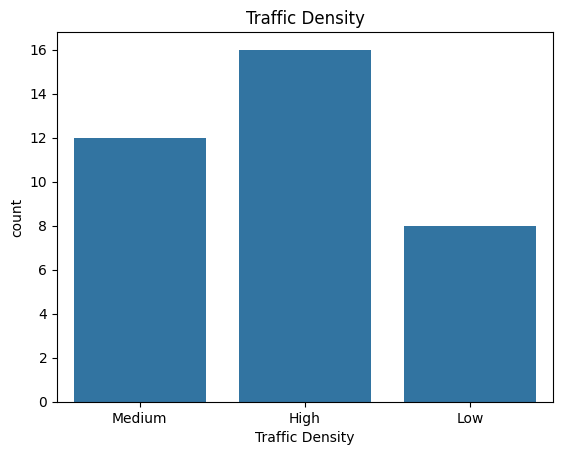

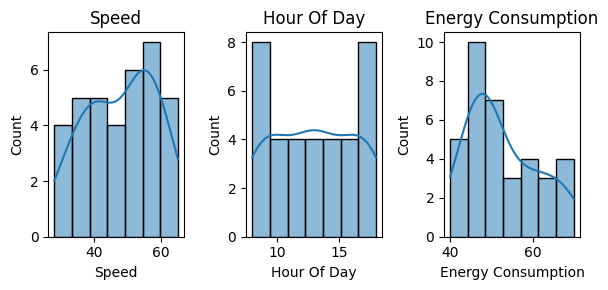

In [4]:
# Categorical
sns.countplot(x='Traffic Density', data=df)
plt.title('Traffic Density')
plt.show()

# Numerical in one row
num_cols = ['Speed', 'Hour Of Day', 'Energy Consumption']
fig, axes = plt.subplots(1, 3, figsize=(6,3))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Insights:**


*  Traffic Density is balanced across Low, Medium, High (approximately 12 each).
*   Speed is roughly normally distributed, ranging from 28 to 65 mph.
*   Energy Consumption varies by vehicle type (higher for buses/trucks).
*   Hour of Day shows peaks around 8, 12, 17 (peak hours).





**Bivariate Analysis**

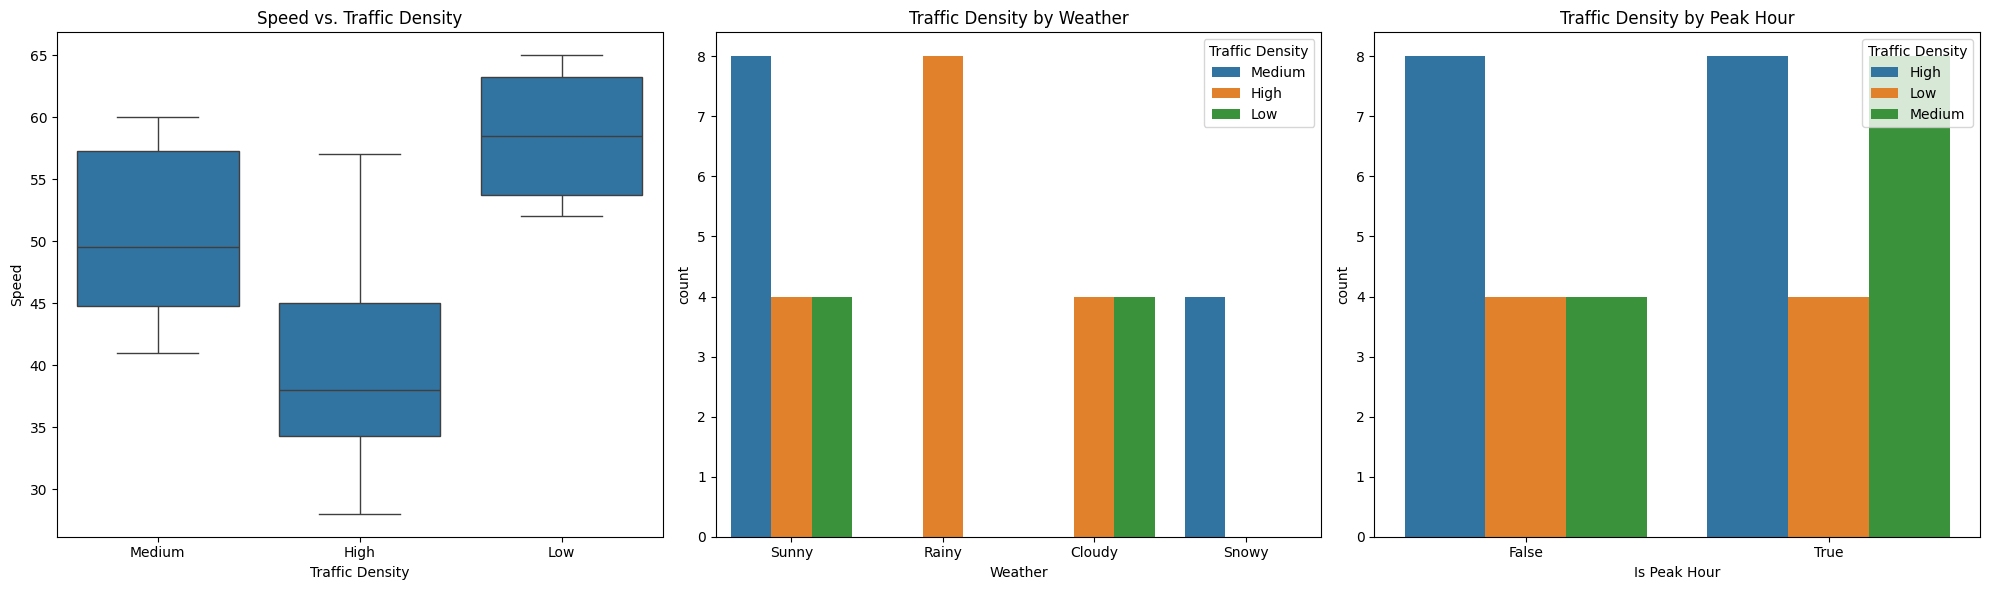

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(x='Traffic Density', y='Speed', data=df, ax=axes[0]).set_title('Speed vs. Traffic Density')
sns.countplot(x='Weather', hue='Traffic Density', data=df, ax=axes[1]).set_title('Traffic Density by Weather')
sns.countplot(x='Is Peak Hour', hue='Traffic Density', data=df, ax=axes[2]).set_title('Traffic Density by Peak Hour')

plt.tight_layout()
plt.show()


**Insights:**


*   Lower speeds correlate with High traffic density.
*   Rainy and snowy weather often leads to High traffic density.

*   Peak hours (True) are associated with Medium/High traffic density.






**Multivariate Analysis**

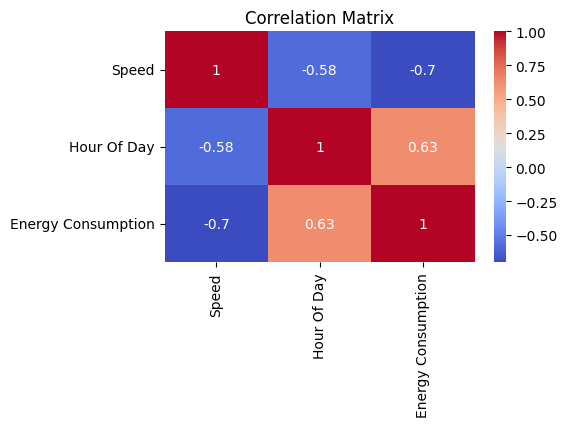

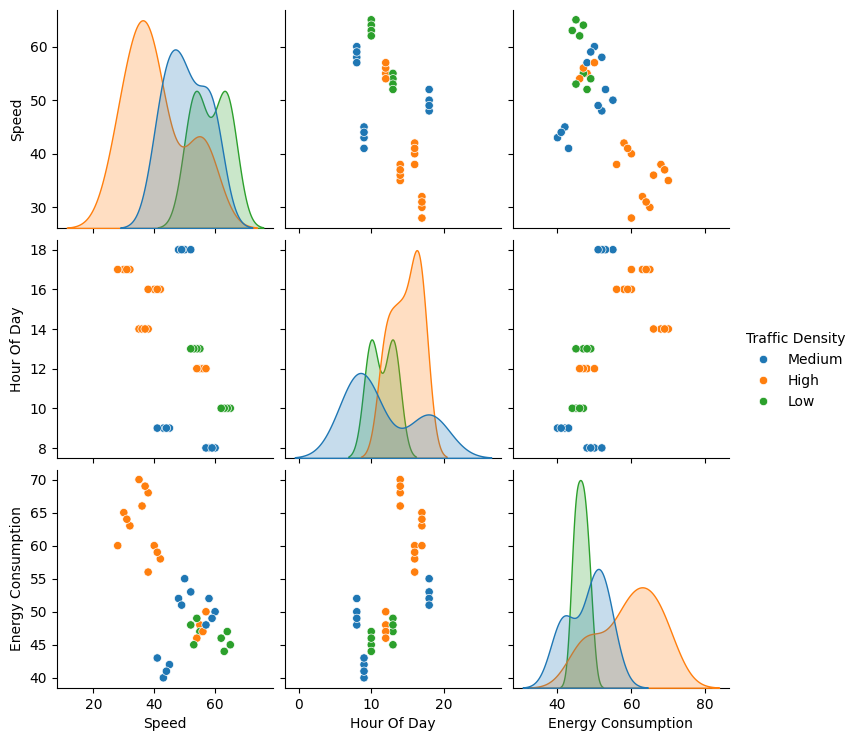

In [6]:
# Correlation matrix for numerical features
plt.figure(figsize=(5,3))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Pairplot for numerical features colored by Traffic Density
sns.pairplot(df, vars=num_cols, hue='Traffic Density')
plt.show()

**Insights:**


*   Speed and Traffic Density have a strong negative correlation (lower speeds in high density).
*   Energy Consumption is higher for buses/trucks, especially in high-density conditions.

*   Hour of Day influences density, with peaks at 8 AM, 12 PM, and 5 PM.






**Data Preprocessing (or) Data Preparation**

In [7]:
# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week', 'Traffic Density']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Convert boolean to int
df['Is Peak Hour'] = df['Is Peak Hour'].astype(int)
df['Random Event Occurred'] = df['Random Event Occurred'].astype(int)

# Define features (X) and target (y)
X = df.drop('Traffic Density', axis=1)
y = df['Traffic Density']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Notes:**



*   Categorical variables (e.g., City, Weather) are label-encoded
*   Boolean columns are converted to 0/1.
*   Numerical features are scaled to ensure models like Logistic Regression perform well.
*   80-20 train-test split for robust evaluation.





In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   City                   36 non-null     int64
 1   Vehicle Type           36 non-null     int64
 2   Weather                36 non-null     int64
 3   Economic Condition     36 non-null     int64
 4   Day Of Week            36 non-null     int64
 5   Hour Of Day            36 non-null     int64
 6   Speed                  36 non-null     int64
 7   Is Peak Hour           36 non-null     int64
 8   Random Event Occurred  36 non-null     int64
 9   Energy Consumption     36 non-null     int64
 10  Traffic Density        36 non-null     int64
dtypes: int64(11)
memory usage: 3.2 KB


**Model Selection**

We’ll select two models for predicting traffic density (a classification task):


1.   **Random Forest Classifier**: Handles non-linear relationships and feature interactions well, suitable for mixed categorical/numerical data.
2.   **Logistic Regression:** A baseline model for interpretability and performance on smaller datasets.





**Model Training**

In [9]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [10]:
# Logistic Regression
lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

**Model Evaluation**


Random Forest Evaluation:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         4
        High       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



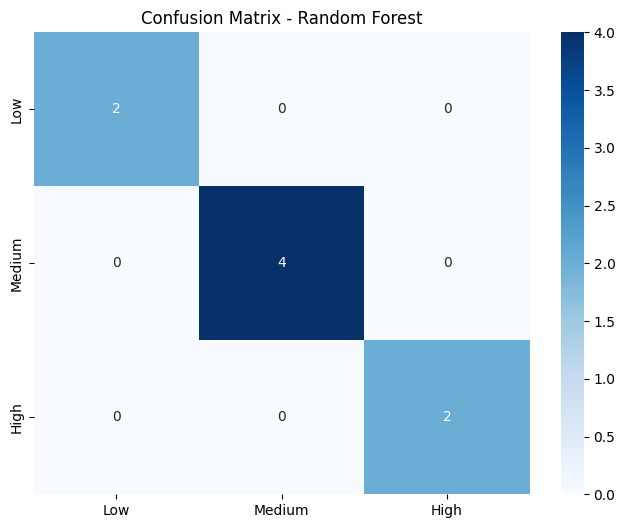


Logistic Regression Evaluation:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         4
        High       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



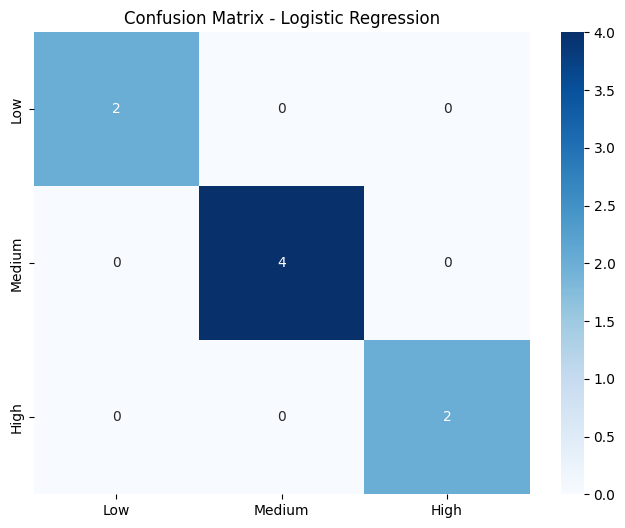

In [11]:
# Function to evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"\n{model_name} Evaluation:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Evaluate both models
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(lr, X_test, y_test, "Logistic Regression")

**Model Tuning and Optimization**

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Evaluation:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         4
        High       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



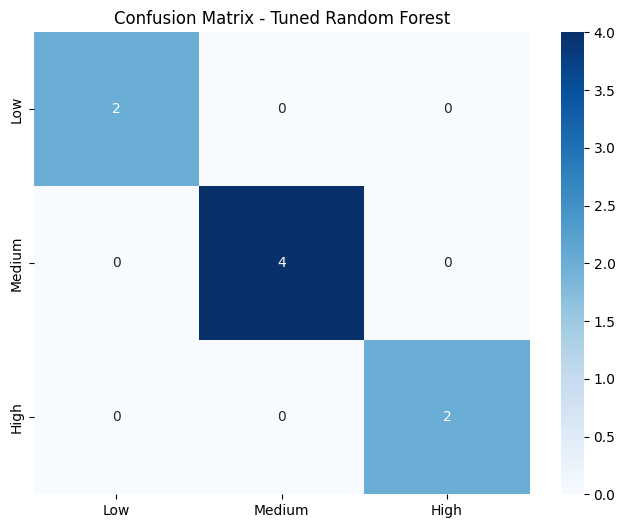

In [12]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Evaluate tuned model
evaluate_model(best_rf, X_test, y_test, "Tuned Random Forest")

**Correlation Matrix**

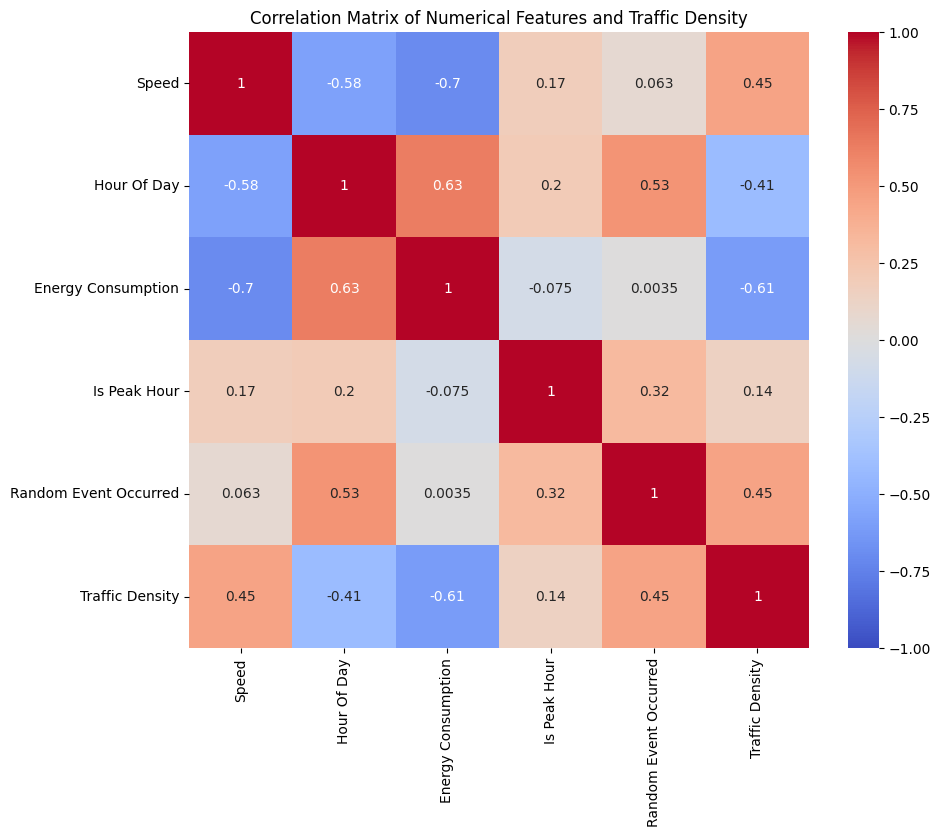

                          Speed  Hour Of Day  Energy Consumption  \
Speed                  1.000000    -0.582107           -0.701829   
Hour Of Day           -0.582107     1.000000            0.626225   
Energy Consumption    -0.701829     0.626225            1.000000   
Is Peak Hour           0.172190     0.199263           -0.075248   
Random Event Occurred  0.062901     0.525105            0.003499   
Traffic Density        0.447845    -0.414971           -0.612157   

                       Is Peak Hour  Random Event Occurred  Traffic Density  
Speed                      0.172190               0.062901         0.447845  
Hour Of Day                0.199263               0.525105        -0.414971  
Energy Consumption        -0.075248               0.003499        -0.612157  
Is Peak Hour               1.000000               0.316228         0.141990  
Random Event Occurred      0.316228               1.000000         0.449013  
Traffic Density            0.141990               0.449

In [13]:
# Create a copy of the dataset with encoded variables
df_corr = df.copy()

# Compute correlation matrix
corr_matrix = df_corr[['Speed', 'Hour Of Day', 'Energy Consumption', 'Is Peak Hour', 'Random Event Occurred', 'Traffic Density']].corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Numerical Features and Traffic Density')
plt.show()

# Display correlation matrix
print(corr_matrix)

**Final Model Testing & Saving:**

In [14]:
# Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']